# MLCOE Task 3

## Part 1 - EDA

dataset - UCI Census Income KDD https://archive.ics.uci.edu/dataset/117/census+income+kdd

picked this one bcz it has around 199523 rows and 40+ columns which is way more than what was needed (150k rows 30 cols). its real census data so its actually messy, has missing values, imbalanced target, not some clean toy dataset

target col is income basically checking if someone makes more than 50k or not

In [9]:
import pandas as pd

In [10]:
import numpy as np

In [11]:
import matplotlib.pyplot as plt

In [12]:
import seaborn as sns

### loading the data

In [13]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\CYBO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
from ucimlrepo import fetch_ucirepo

In [15]:
census_income_kdd = fetch_ucirepo(id=117)

In [16]:
X = census_income_kdd.data.features

In [17]:
y = census_income_kdd.data.targets

In [18]:
df = X.copy()

In [19]:
df['income'] = y.iloc[:, 0]

In [20]:
df.shape

(199523, 42)

In [21]:
df.head()

,AAGE,ACLSWKR,ADTINK,ADTOCC,AHGA,AHSCOL,AMARITL,AMJIND,AMJOCC,ARACE,...,PEMNTVTY,PENATVTY,PRCITSHP,SEOTR,VETQVA,VETYN,WKSWORK,AHRSPAY,year,income
0,73,Not in universe,0,0,High school graduate,Not in universe,Widowed,Not in universe or children,Not in universe,White,...,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,0,95,-50000
1,58,Self-employed-not incorporated,4,34,Some college but no degree,Not in universe,Divorced,Construction,Precision production craft & repair,White,...,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,0,94,-50000
2,18,Not in universe,0,0,10th grade,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,...,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,0,95,-50000
3,9,Not in universe,0,0,Children,Not in universe,Never married,Not in universe or children,Not in universe,White,...,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,0,94,-50000
4,10,Not in universe,0,0,Children,Not in universe,Never married,Not in universe or children,Not in universe,White,...,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,0,94,-50000


renaming the columns bcz they came in as weird short codes like AAGE AHGA etc, easier to work with readable names

In [22]:
df = df.rename(columns={
    'AAGE': 'age', 'ACLSWKR': 'class_of_worker', 'ADTINK': 'industry_code',
    'ADTOCC': 'occupation_code', 'AHGA': 'education', 'AHSCOL': 'enrolled_in_edu_last_wk',
    'AMARITL': 'marital_status', 'AMJIND': 'major_industry_code', 'AMJOCC': 'major_occupation_code',
    'ARACE': 'race', 'AREORGN': 'hispanic_origin', 'ASEX': 'sex', 'AUNMEM': 'labor_union_member',
    'AUNTYPE': 'reason_for_unemployment', 'AWKSTAT': 'employment_status', 'CAPGAIN': 'capital_gain',
    'GAPLOSS': 'capital_loss', 'DIVVAL': 'dividends_from_stocks', 'FILESTAT': 'tax_filer_status',
    'GRINREG': 'region_prev_residence', 'GRINST': 'state_prev_residence', 'HHDFMX': 'household_family_stat',
    'HHDREL': 'household_summary', 'MARSUPWRT': 'instance_weight', 'MIGMTR1': 'migration_msa',
    'MIGMTR3': 'migration_reg', 'MIGMTR4': 'migration_within_reg', 'MIGSAME': 'lived_here_1yr_ago',
    'MIGSUN': 'migration_sunbelt', 'NOEMP': 'num_persons_worked_for', 'PARENT': 'family_members_under_18',
    'PEFNTVTY': 'father_birth_country', 'PEMNTVTY': 'mother_birth_country', 'PENATVTY': 'self_birth_country',
    'PRCITSHP': 'citizenship', 'SEOTR': 'self_employed', 'VETQVA': 'veteran_admin_questionnaire',
    'VETYN': 'veterans_benefits', 'WKSWORK': 'weeks_worked', 'AHRSPAY': 'wage_per_hour'
})

### structural check

In [23]:
df.shape

(199523, 42)

In [24]:
df.columns.tolist()

['age',
 'class_of_worker',
 'industry_code',
 'occupation_code',
 'education',
 'enrolled_in_edu_last_wk',
 'marital_status',
 'major_industry_code',
 'major_occupation_code',
 'race',
 'hispanic_origin',
 'sex',
 'labor_union_member',
 'reason_for_unemployment',
 'employment_status',
 'capital_gain',
 'capital_loss',
 'dividends_from_stocks',
 'tax_filer_status',
 'region_prev_residence',
 'state_prev_residence',
 'household_family_stat',
 'household_summary',
 'instance_weight',
 'migration_msa',
 'migration_reg',
 'migration_within_reg',
 'lived_here_1yr_ago',
 'migration_sunbelt',
 'num_persons_worked_for',
 'family_members_under_18',
 'father_birth_country',
 'mother_birth_country',
 'self_birth_country',
 'citizenship',
 'self_employed',
 'veteran_admin_questionnaire',
 'veterans_benefits',
 'weeks_worked',
 'wage_per_hour',
 'year',
 'income']

In [25]:
df.dtypes

age                              int64
class_of_worker                    str
industry_code                    int64
occupation_code                  int64
education                          str
enrolled_in_edu_last_wk            str
marital_status                     str
major_industry_code                str
major_occupation_code              str
race                               str
hispanic_origin                    str
sex                                str
labor_union_member                 str
reason_for_unemployment            str
employment_status                  str
capital_gain                     int64
capital_loss                     int64
dividends_from_stocks            int64
tax_filer_status                   str
region_prev_residence              str
state_prev_residence               str
household_family_stat              str
household_summary                  str
instance_weight                float64
migration_msa                      str
migration_reg            

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          199523 non-null  int64  
 1   class_of_worker              199523 non-null  str    
 2   industry_code                199523 non-null  int64  
 3   occupation_code              199523 non-null  int64  
 4   education                    199523 non-null  str    
 5   enrolled_in_edu_last_wk      199523 non-null  str    
 6   marital_status               199523 non-null  str    
 7   major_industry_code          199523 non-null  str    
 8   major_occupation_code        199523 non-null  str    
 9   race                         199523 non-null  str    
 10  hispanic_origin              199523 non-null  str    
 11  sex                          199523 non-null  str    
 12  labor_union_member           199523 non-null  str    
 13  reason_for

so around 199523 rows 42 columns. most cols are object/text type not numeric which makes sense for census data, stuff like occupation education marital status are categories not numbers, only a handful cols like age capital_gain wage_per_hour etc are actually numeric

### missing values and duplicates

In [27]:
df.isnull().sum()

age                                0
class_of_worker                    0
industry_code                      0
occupation_code                    0
education                          0
enrolled_in_edu_last_wk            0
marital_status                     0
major_industry_code                0
major_occupation_code              0
race                               0
hispanic_origin                    0
sex                                0
labor_union_member                 0
reason_for_unemployment            0
employment_status                  0
capital_gain                       0
capital_loss                       0
dividends_from_stocks              0
tax_filer_status                   0
region_prev_residence              0
state_prev_residence             708
household_family_stat              0
household_summary                  0
instance_weight                    0
migration_msa                  99696
migration_reg                  99696
migration_within_reg           99696
l

In [28]:
df.duplicated().sum()

np.int64(3229)

In [30]:
df = df.drop_duplicates()

In [31]:
df = df.drop(columns=['migration_msa', 'migration_reg', 'migration_within_reg', 'migration_sunbelt'])

In [32]:
df['father_birth_country'] = df['father_birth_country'].fillna('Unknown')

In [33]:
df['mother_birth_country'] = df['mother_birth_country'].fillna('Unknown')

In [34]:
df['self_birth_country'] = df['self_birth_country'].fillna('Unknown')

In [35]:
df['state_prev_residence'] = df['state_prev_residence'].fillna('Unknown')

In [36]:
df.isnull().sum().sum()

np.int64(0)

In [132]:
df.shape

(196294, 40)

the 4 migration cols had like 99k missing each basically half the data, dropped them completely bcz that makes sense too, these are ppl who didnt move in the last year so the question just wasnt applicable to them in the first place

state_prev_residence and the birth country cols had way less missing like under 7k so filled with Unknown instead of dropping rows, not worth losing that much data over such a small percent missing

also noticed class_of_worker has this category called Not in universe with about 100k rows in it, thats not actually missing data its literally saying the question doesnt apply to that person, like a kid or someone retired who isnt working, so left that one alone didnt touch it

duplicates were 3229 rows that were exact copies across every single column, just dropped those

### distributions and outliers

In [37]:
df.describe()

,age,industry_code,occupation_code,capital_gain,capital_loss,dividends_from_stocks,instance_weight,num_persons_worked_for,self_employed,veterans_benefits,weeks_worked,wage_per_hour,year
count,196294.000000,196294.000000,196294.000000,196294.000000,196294.000000,196294.000000,196294.000000,196294.000000,196294.000000,196294.000000,196294.000000,196294.000000,196294.000000
mean,34.929468,15.603187,11.490468,441.870037,37.927593,200.722386,1743.267584,1.988105,0.178304,1.538183,23.553889,56.336505,94.499328
std,22.210001,18.106401,14.498128,4735.677027,274.081174,2000.130616,996.945985,2.371018,0.557739,0.836813,24.428588,277.054333,0.500001
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,37.870000,0.000000,0.000000,0.000000,0.000000,0.000000,94.000000
25%,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1061.530000,0.000000,0.000000,2.000000,0.000000,0.000000,94.000000
50%,34.000000,1.000000,2.000000,0.000000,0.000000,0.000000,1620.175000,1.000000,0.000000,2.000000,12.000000,0.000000,94.000000
75%,50.000000,33.000000,26.000000,0.000000,0.000000,0.000000,2194.060000,4.000000,0.000000,2.000000,52.000000,0.000000,95.000000
max,90.000000,51.000000,46.000000,99999.000000,4608.000000,99999.000000,18656.300000,6.000000,2.000000,2.000000,52.000000,9999.000000,95.000000


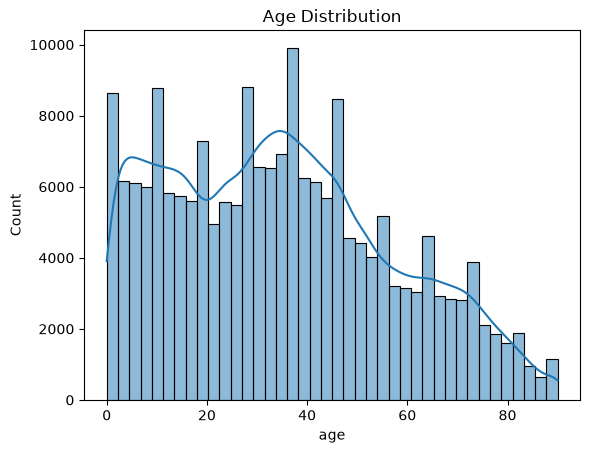

In [ ]:
sns.histplot(df['age'], bins=40)
plt.title('Age Distribution')
plt.show()

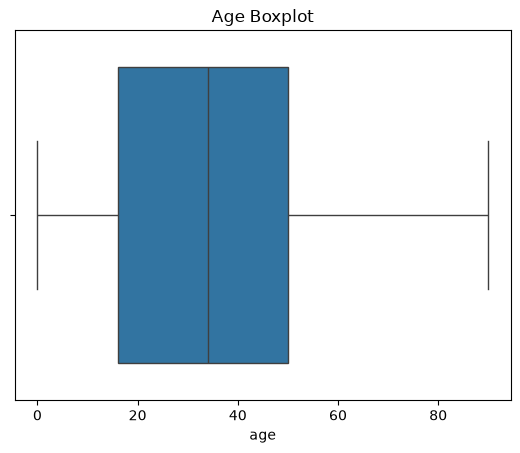

In [39]:
sns.boxplot(x=df['age'])
plt.title('Age Boxplot')
plt.show()

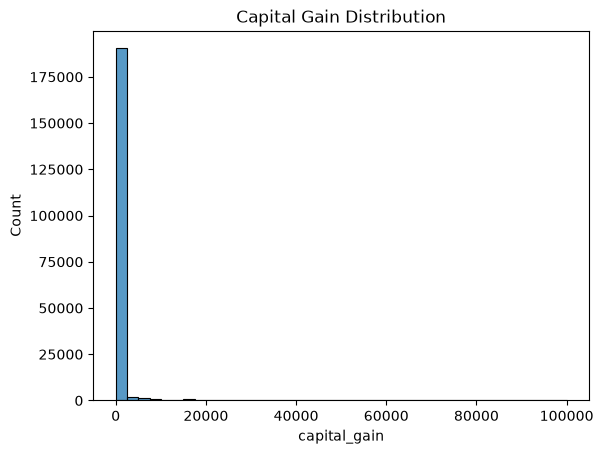

In [40]:
sns.histplot(df['capital_gain'], bins=40)
plt.title('Capital Gain Distribution')
plt.show()

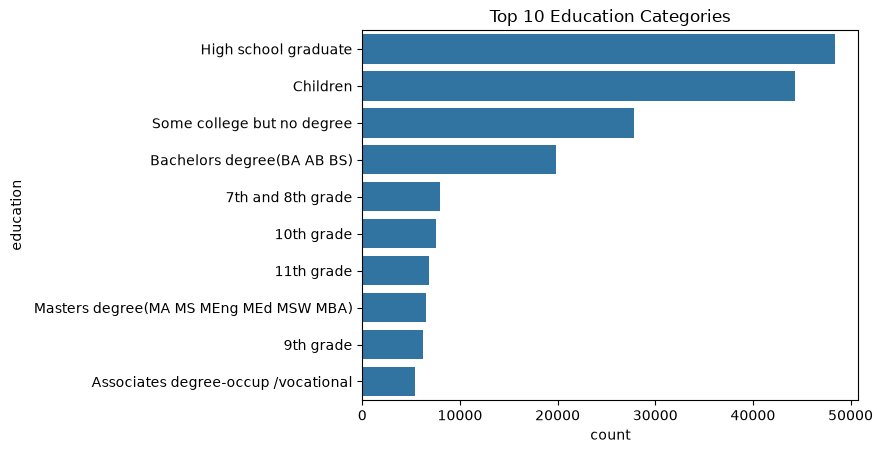

In [41]:
sns.countplot(y=df['education'], order=df['education'].value_counts().index[:10])
plt.title('Top 10 Education Categories')
plt.show()

age is roughly bell shaped but theres a bump at the low end too since kids are counted in this dataset not just working age adults

capital_gain is insanely skewed basically everyone sits at 0 except a small chunk of ppl who have actual investment income, makes sense. also noticed in describe() that capital_gain and wage_per_hour have these weird round max values like 99999 and 9999, thats not a data error, census bureau does this on purpose to cap extreme values so it doesnt reveal exactly who the super high earners are

education wise high school graduate is the most common category by far

### relationships

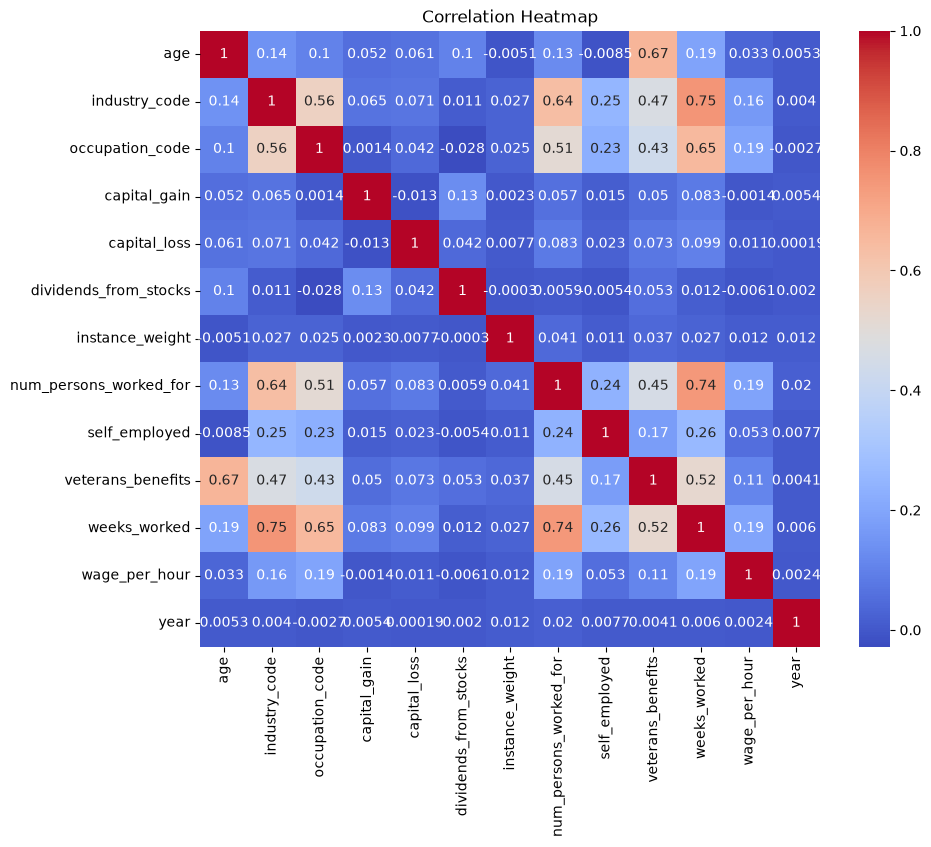

In [ ]:
nc = df.select_dtypes(include=np.number).columns.tolist()
sns.heatmap(df[nc].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

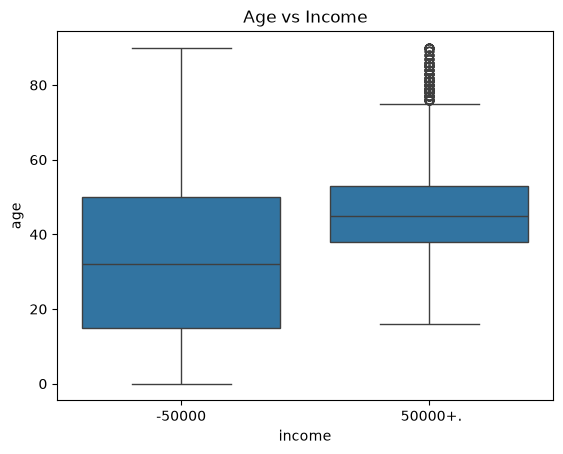

In [43]:
sns.boxplot(data=df, x='income', y='age')
plt.title('Age vs Income')
plt.show()

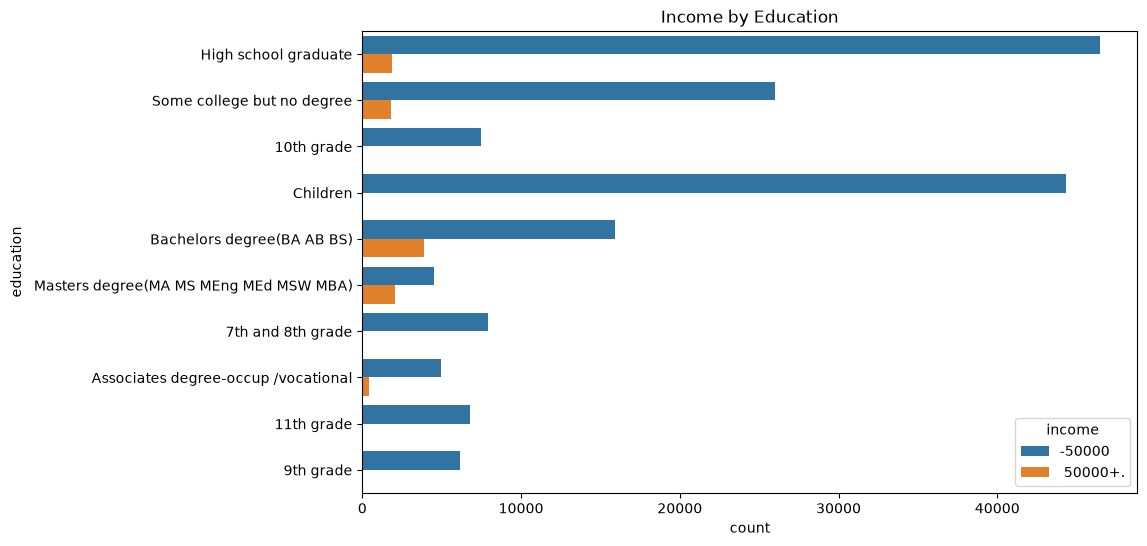

In [44]:
top_edu = df['education'].value_counts().index[:10]
subset = df[df['education'].isin(top_edu)]

plt.figure(figsize=(10,6))
sns.countplot(data=subset, y='education', hue='income')
plt.title('Income by Education')
plt.show()

numeric cols dont really correlate much with each other so not a lot of redundancy there, means pca prob wont shrink things down super dramatically since most of the real useful info is prob sitting in the categorical columns instead of numeric ones

ppl earning 50000+ are mostly clustered in the 35 to 55 age range which lines up with typical peak earning years, both very young and older ppl skew towards lower income

education clearly matters too, higher education level = way more ppl crossing the 50k mark, 

### feature engineering

In [ ]:
df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,55,65,100],labels=['<25','25-34','35-44','45-54','55-64','65+'])

In [46]:
df['has_capital_gains'] = (df['capital_gain'] > 0).astype(int)

made age groups instead of using raw age bcz income doesnt increase in a straight line with age, it climbs then kinda flattens out, so buckets should help the model pick up on that pattern easier than a raw number

also added a simple 0/1 flag for having any capital gains since the actual capital_gain number is basically all zeros anyway with a few big outliers, so just checking presence/absence of investment income is prob a cleaner signal than the raw skewed column

## Part 2 - PCA

doing this manually with numpy, not using sklearn PCA class

In [47]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('instance_weight')

In [48]:
X_pca = df[numeric_cols]

In [49]:
from sklearn.preprocessing import StandardScaler

In [50]:
scaler = StandardScaler()

In [51]:
X_scaled = scaler.fit_transform(X_pca)

covariance matrix first

In [52]:
cov_matrix = np.cov(X_scaled.T)

In [53]:
cov_matrix.shape

(13, 13)

now eigenvalues and eigenvectors from that

In [54]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [55]:
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_idx]
eigenvectors_sorted = eigenvectors[:, sorted_idx]

In [56]:
explained_variance_ratio = eigenvalues_sorted / np.sum(eigenvalues_sorted)
cumulative_variance = np.cumsum(explained_variance_ratio)

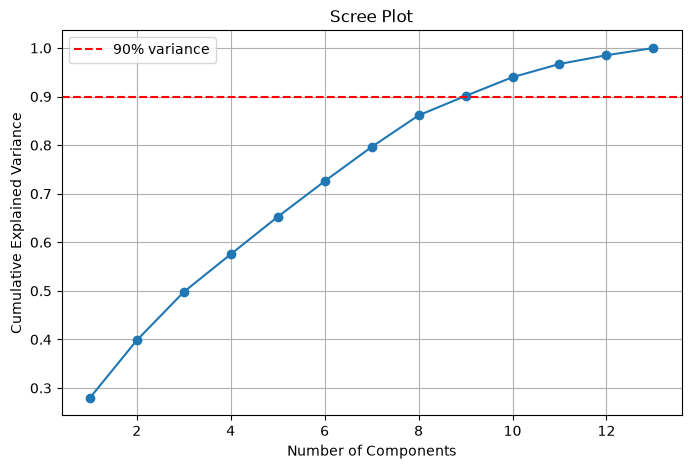

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance.real, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.legend()
plt.grid(True)
plt.show()

check the graph above and see how many components cross 90 percent, set that number below

In [138]:
X_scaled.shape

(196294, 13)

In [58]:
N_COMPONENTS = 8

In [59]:
top_eigenvectors = eigenvectors_sorted[:, :N_COMPONENTS].real

In [136]:
top_eigenvectors.shape

(13, 8)

In [60]:
X_pca_transformed = X_scaled.dot(top_eigenvectors)

In [137]:
X_pca_transformed.shape

(196294, 8)

In [61]:
X_pca_transformed.shape

(196294, 8)

a principal component is basically a new direction thats made by mixing the original columns together in a way that grabs as much of the spread/variance in the data as possible. first component grabs the most variance, the next one grabs the next biggest chunk while staying perpendicular to the first, and so on. so instead of carrying around all the original numeric columns we can just look at a handful of these new components and still keep most of the info

dimensionality reduction is useful here in general but since our numeric columns werent that correlated to begin with (saw that in the heatmap earlier) the compression isnt gonna be super dramatic, most of the real signal in this dataset is prob in the categorical columns not the numeric ones

## Part 3 - clustering 

kmeans - pick k random starting centroids, assign every point to whichever centroid is closest, recalculate centroids as the average of whatever got assigned to it, keep repeating until centroids stop moving. picking k usually done with elbow method (plot error vs k and find the bend) or silhouette score. works best when data naturally forms round evenly sized blobs

dbscan - instead of centroids it looks at density. a point counts as core if it has enough neighbors (min_samples) within some radius (eps). clusters get built by chaining together nearby dense regions. points that dont belong to any dense region just get called noise instead of being forced into a cluster, thats the main diff from kmeans since kmeans forces literally every single point into some cluster no matter how badly it fits. dbscan handles weird shaped clusters and actual outliers way better because of this

when would clustering help on this dataset - even tho not implementing it here, could use it to group ppl into natural segments based on profile like education job demographics without even touching the income label, might reveal stuff like a young highly educated high earning cluster that a plain classifier wouldnt directly surface on its own

## Part 4 - Ensemble Learning

target is income, binary classification problem, does someone earn more than 50000 or not. good target bcz its literally what the dataset is built around and its a genuinely non trivial prediction task, need to combine a bunch of features together to actually predict it well which is exactly why ensemble models make sense here

In [62]:
df['income'] = df['income'].apply(lambda x: 1 if '50000+' in str(x) else 0)

In [63]:
df['income'].value_counts()

income
0    183912
1     12382
Name: count, dtype: int64

only a small chunk of ppl actually cross 50k here so plain accuracy is gonna look artificially good even for a weak model, gonna rely more on precision recall f1 and the confusion matrix instead

In [64]:
df_model = df.drop(columns=['instance_weight'])

In [65]:
df_encoded = pd.get_dummies(df_model, drop_first=True)

In [66]:
df_encoded.shape

(196294, 358)

onehot encoding blows up the column count a good bit since stuff like state and country cols have tons of categories, might make training kinda slow. if its too slow on your machine just drop state_prev_residence father_birth_country mother_birth_country self_birth_country before encoding, they add a lot of columns for not that much benefit anyway

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X = df_encoded.drop(columns=['income'])

incom as output

In [69]:
y = df_encoded['income']

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [71]:
X_train.shape, X_test.shape

((157035, 357), (39259, 357))

### training all three models

In [104]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

In [105]:
from xgboost import XGBClassifier

In [106]:
rf = RandomForestClassifier(random_state=42)

In [107]:
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [108]:
ada = AdaBoostClassifier(random_state=42)

In [109]:
ada.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.06,0.26,0.28,...,0.47,0.47,0.47]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[2.81,1.06,0.92,...,0.14,0.12,0.12]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](357,)","[0.16,0. ,0.07,...,0. ,0. ,0. ]"


In [110]:
import re

X_train.columns = [re.sub(r'[<>\[\]]', '', col) for col in X_train.columns]
X_test.columns = [re.sub(r'[<>\[\]]', '', col) for col in X_test.columns]

In [111]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

In [112]:
xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### evaluating

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate(model, name):
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
    print(confusion_matrix(y_test, preds))
    print()
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

In [114]:
results = []

In [115]:
results.append(evaluate(rf, 'Random Forest'))

--- Random Forest ---
Accuracy: 0.9524  Precision: 0.7384  Recall: 0.3796  F1: 0.5015
[[36450   333]
 [ 1536   940]]



In [116]:
results.append(evaluate(ada, 'AdaBoost'))

--- AdaBoost ---
Accuracy: 0.9475  Precision: 0.6745  Recall: 0.3239  F1: 0.4377
[[36396   387]
 [ 1674   802]]



In [117]:
results.append(evaluate(xgb, 'XGBoost'))

--- XGBoost ---
Accuracy: 0.9561  Precision: 0.7257  Recall: 0.4883  F1: 0.5838
[[36326   457]
 [ 1267  1209]]



In [118]:
results_df = pd.DataFrame(results)

In [119]:
results_df

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.952393,0.738413,0.379645,0.501467
1,AdaBoost,0.947502,0.674516,0.323910,0.437653
2,XGBoost,0.956087,0.725690,0.488288,0.583776


whichever model has the highest f1 here is prob the one id call best since accuracy alone is misleading with how imbalanced this dataset is

### feature importance

In [120]:
importances_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

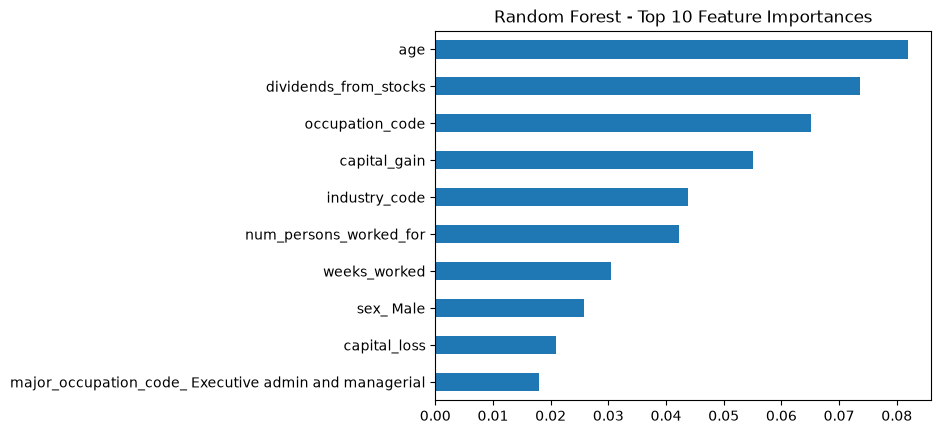

In [121]:
importances_rf.head(10).plot(kind='barh')
plt.title('Random Forest - Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

In [122]:
importances_xgb = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

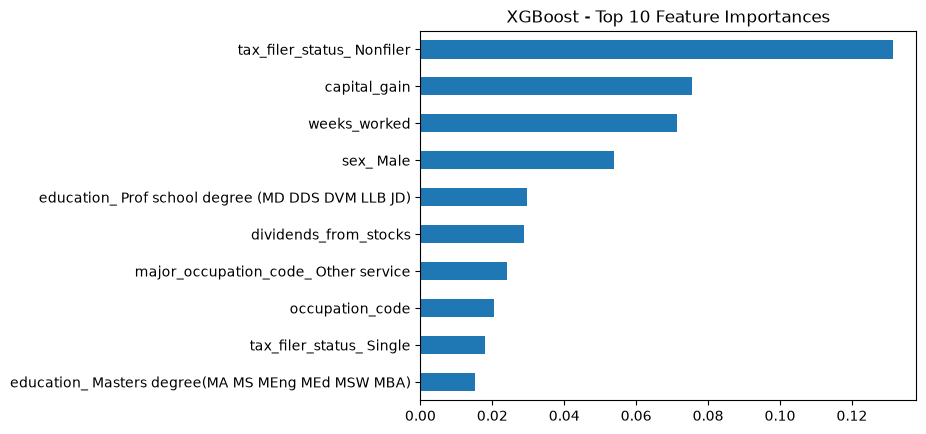

In [123]:
importances_xgb.head(10).plot(kind='barh')
plt.title('XGBoost - Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

random forest - bagging technique. trains a bunch of decision trees independently and in parallel, each tree gets a random bootstrapped sample of rows plus a random subset of features so no two trees see exactly the same thing. final prediction is just majority vote across all the trees. since each trees mistakes are kinda independent from each other averaging them out cancels a lot of the noise and overfitting

adaboost - boosting technique so trees get built one after another instead of parallel. first tree does its thing then whatever rows it got wrong get their weight bumped up so the next tree focuses more on those harder examples, keeps repeating and the final prediction is a weighted vote across every tree. this helps fix systematic bias but can get thrown off by noisy data since itll keep focusing on those noisy points thinking theyre hard patterns worth learning

xgboost - also boosting but more refined, instead of just reweighting wrong samples like adaboost each new tree is trained to predict the leftover residual/error from the current combined model which is basically gradient boosting, plus it adds regularization so trees dont get too complex and overfit. thats usually why it beats plain adaboost, its optimizing the loss more precisely while also controlling overfitting at the same time

## Part 5 - Export

In [124]:
import joblib

In [125]:
best_model = xgb

In [126]:
joblib.dump(best_model, 'best_model.pkl')

['best_model.pkl']

In [127]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [128]:
joblib.dump(list(X.columns), 'model_columns.pkl')

['model_columns.pkl']

In [129]:
loaded_model = joblib.load('best_model.pkl')

In [130]:
sample_prediction = loaded_model.predict(X_test.iloc[:5])

In [131]:
sample_prediction

array([1, 0, 0, 0, 1])

## Part 6 - Streamlit

see app.py, it loads the saved model and takes user input then shows a prediction. run it with

streamlit run app.py

needs best_model.pkl scaler.pkl and model_columns.pkl in the same folder